<a href="https://www.kaggle.com/code/mohammednafayali/fake-news-detection-bow-vs-tf-idf-benc?scriptVersionId=340513594" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import warnings
warnings.simplefilter("ignore")

/kaggle/input/datasets/mobeenfatimah/fake-news-detection-dataset-6000-news-articles/news_dataset.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/mobeenfatimah/fake-news-detection-dataset-6000-news-articles/news_dataset.csv")
df.head(20)

,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1
5,SHOCKER! A LIBERAL TAKEDOWN Of Hillary Clinton...,,politics,"Sep 26, 2016",0
6,"Trump STRANDED, In Full Panic As ANOTHER Perf...",President-elect Donald Trump has had trouble f...,News,"January 16, 2017",0
7,FOOTBALL LEGEND JIM KELLY: “Donald Trump took ...,https://www.youtube.com/watch?v=gqxwF-TeYas,politics,"Jan 28, 2017",0
8,This One Car Could Overthrow The Governments ...,"For more than a century, countries around the ...",News,"April 1, 2016",0
9,New Expose Details Just How Terrible Donald T...,Americans can thank that pesky liberal media f...,News,"May 15, 2016",0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB


In [4]:
df=df.drop(columns=["subject","date"],errors="ignore")
df

,title,text,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,1
...,...,...,...
5995,Exiled Venezuelan opposition magistrates resur...,SANTIAGO (Reuters) - A group of opposition-app...,1
5996,Plague outbreak in Madagascar kills 20: WHO,NAIROBI (Reuters) - An outbreak of plague has ...,1
5997,"Trump to visit Asia in November, North Korea i...",WASHINGTON (Reuters) - Donald Trump will trave...,1
5998,Melania Trump calls taped comments by Donald T...,(Reuters) - Melania Trump rose to her husband’...,1


In [5]:
df['full_text'] = df['title'] + " " + df['text']
df = df[['full_text', 'label']]
df.head()

,full_text,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,0
1,"China backs U.N. call for justice in Yemen, U....",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,0
4,Lawmakers aim to delay U.S. ceding control of ...,1


In [6]:

df["label"].value_counts()

label
0    3000
1    3000
Name: count, dtype: int64

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [8]:
X=df["full_text"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:

leakage_words = {
    'reuters', 'said', 'washington', 'tuesday', 'wednesday', 'thursday', 'friday', 
    'monday', 'saturday', 'sunday', 'via', 'video', 'image', 'featured', 'twitter',
    'facebook', 'post', 'getty', 'images','senate', 'house', 'told', 'reporters', 'presidential', 'spokesman', 'minister', 'republican', 'us', 'trumps'
,'hillary', 'america', 'gop', 'obama', 'like', 'even', 'watch', 'trump', 'wire', 'one','whether', 'comment', 'clintons', 'court', 'percent', 'representatives', 'democratic', 'would', 'statement', 'nov','black', 'mr', 'clinton', 'americans', '21st', 'american', 'actually', 'really', 'century', 'fact'
}

# Update your stop_words set
stop_words = set(stopwords.words('english')).union(leakage_words) - {'not', 'no', 'nor', 'neither'}

def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)
    


X_train = X_train.apply(clean_text)

X_test = X_test.apply(clean_text)


In [10]:
tfidf = TfidfVectorizer(max_features=5000,min_df=5, ngram_range=(1,1))
tfidf_X_train = tfidf.fit_transform(X_train)
tfidf_X_test = tfidf.transform(X_test)

bow = CountVectorizer(max_features=5000,min_df=5, ngram_range=(1, 1))
bow_X_train = bow.fit_transform(X_train)
bow_X_test = bow.transform(X_test)

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVC (Linear)": SVC(kernel="linear"),
    "MultinomialNB": MultinomialNB(),
    "XGBClassifier": XGBClassifier()
}

vectorizers = {
    "Bag of Words": (bow_X_train, bow_X_test),
    "TF-IDF": (tfidf_X_train, tfidf_X_test)
}

results = {}
trained_models = {}

print("=" * 60)
print(" 🚀 STARTING MODEL BENCHMARKING (ON HELD-OUT TEST SET) ")
print("=" * 60)

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f"\n📌 Approach: {vec_name}")
    print("-" * 50)
    
    for model_name, model_obj in models.items():
        
        model = model_obj.__class__(**model_obj.get_params())
        model.fit(X_tr, y_train)
        
        y_pred = model.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        
        combo_key = f"{model_name} with {vec_name}"
        results[combo_key] = acc
        trained_models[combo_key] = (model, y_pred)
        
        print(f"  • {model_name:<20} | Test Accuracy: {acc * 100:.2f}%")

print("\n" + "=" * 60)
best_combo = max(results, key=results.get)
best_score = results[best_combo]

print(f"🏆 OVERALL WINNER: {best_combo}")
print(f"🎯 Final Test Accuracy: {best_score * 100:.2f}%")
print("=" * 60)

 🚀 STARTING MODEL BENCHMARKING (ON HELD-OUT TEST SET) 

📌 Approach: Bag of Words
--------------------------------------------------
  • LogisticRegression   | Test Accuracy: 93.17%
  • SVC (Linear)         | Test Accuracy: 90.92%
  • MultinomialNB        | Test Accuracy: 90.67%
  • XGBClassifier        | Test Accuracy: 93.75%

📌 Approach: TF-IDF
--------------------------------------------------
  • LogisticRegression   | Test Accuracy: 93.42%
  • SVC (Linear)         | Test Accuracy: 95.17%
  • MultinomialNB        | Test Accuracy: 89.92%
  • XGBClassifier        | Test Accuracy: 93.83%

🏆 OVERALL WINNER: SVC (Linear) with TF-IDF
🎯 Final Test Accuracy: 95.17%


Detailed Classification Report for SVC (Linear) with TF-IDF:

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       600
           1       0.94      0.97      0.95       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



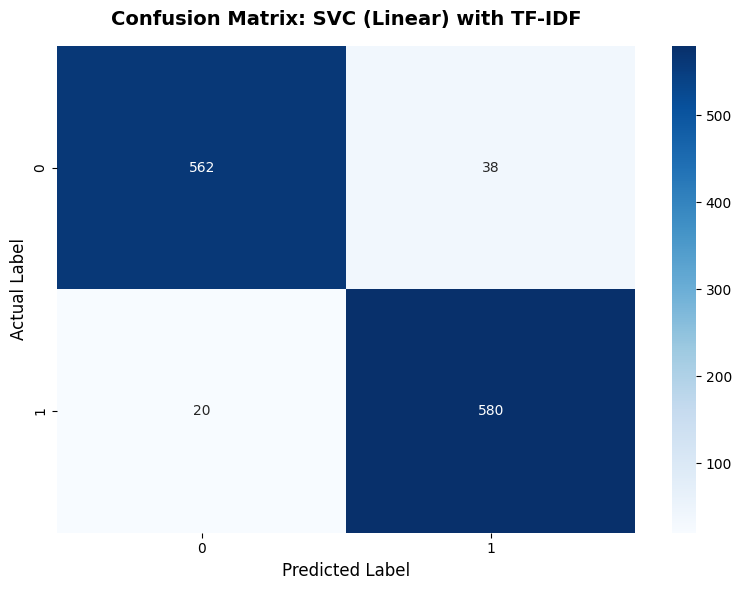

In [12]:
_, winning_preds = trained_models[best_combo]

print(f"Detailed Classification Report for {best_combo}:\n")
print(classification_report(y_test, winning_preds))


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, winning_preds)
labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.title(f'Confusion Matrix: {best_combo}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
import joblib

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

best_model = trained_models['SVC (Linear) with TF-IDF'][0]
joblib.dump(best_model, 'fake_news_model.pkl')

print("Model and Vectorizer successfully saved!")


Model and Vectorizer successfully saved!
